# Etap 3. Eksploracyjna analiza danych (Exploratory data analysis)

In [1]:
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)

customers_features= pd.read_csv(r'C:\Users\l\Documents\DATA_SCIENCE_KURS\PROJEKT_PREDYCJI_SUBSKRYBCJI_NEWSLETTERA\PROJEKT\b_oprzadek\data\customers_features.csv')

customers_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            1000 non-null   str    
 1   name                   1000 non-null   str    
 2   age                    1000 non-null   int64  
 3   state                  1000 non-null   str    
 4   signup_date            1000 non-null   str    
 5   email                  1000 non-null   str    
 6   phone_number           1000 non-null   int64  
 7   subscribe              1000 non-null   int64  
 8   customer_tenture_days  1000 non-null   int64  
 9   gender_Male            1000 non-null   bool   
 10  transaction_count      1000 non-null   int64  
 11  total_spent            1000 non-null   int64  
 12  avg_transaction_value  1000 non-null   float64
 13  total_quantity         1000 non-null   int64  
 14  avg_discount           1000 non-null   float64
 15  unique_products 

### Analiza kolumny 'state'

In [50]:
print(customers_features['state'].nunique())
subsribe_state_value = customers_features.groupby("state")["subscribe"].value_counts(normalize=True)
total_subscribers = customers_features["subscribe"].value_counts(normalize=True)
print(subsribe_state_value)
print(total_subscribers)

35
state             subscribe
Aceh              1            0.787879
                  0            0.212121
Bali              1            0.769231
                  0            0.230769
Banten            1            0.833333
                                 ...   
Sumatera Selatan  0            0.240000
Sumatera Utara    1            0.636364
                  0            0.363636
unknown           1            0.660377
                  0            0.339623
Name: proportion, Length: 70, dtype: float64
subscribe
1    0.711
0    0.289
Name: proportion, dtype: float64


Kolumna state zawierała 35 kategorii. Analiza rozkładu zmiennej docelowej względem stanu wykazała, że udział subskrybentów w poszczególnych stanach jest zbliżony do udziału w całej populacji (71,1%). W związku z tym uznano, że cecha wnosi niewielką dodatkową informację, a jej kodowanie metodą One-Hot zwiększyłoby liczbę zmiennych bez wyraźnych korzyści.

## Statystyki opisowe

In [2]:
#Wybieramy tylko zmienne numeryczne
numeric_features = [
    "subscribe",
    "age",
    "gender_Male",
    "customer_tenture_days",
    "transaction_count",
    "total_spent",
    "avg_transaction_value",
    "total_quantity",
    "unique_products",
    "avg_discount"
]

customers_features[numeric_features].describe().T

,count,mean,std,min,25%,50%,75%,max
subscribe,1000.0,7.110000e-01,4.535247e-01,0.0,0.000000e+00,1.00,1.000000e+00,1.0
age,1000.0,4.119200e+01,1.348306e+01,18.0,2.900000e+01,42.00,5.200000e+01,65.0
customer_tenture_days,1000.0,3.649610e+02,2.053289e+02,0.0,1.887500e+02,367.00,5.330000e+02,730.0
transaction_count,1000.0,8.199000e+00,4.430240e+00,1.0,4.000000e+00,8.00,1.200000e+01,27.0
total_spent,1000.0,5.579279e+07,3.966467e+07,8400.0,2.379925e+07,48816500.00,8.186850e+07,250201000.0
avg_transaction_value,1000.0,6.802236e+06,3.408847e+06,8400.0,4.139714e+06,6969222.22,8.723183e+06,48790000.0
total_quantity,1000.0,1.834630e+02,1.144793e+02,1.0,8.900000e+01,167.50,2.650000e+02,753.0
unique_products,1000.0,8.199000e+00,4.430240e+00,1.0,4.000000e+00,8.00,1.200000e+01,27.0
avg_discount,1000.0,2.364653e+01,6.738927e+00,0.0,2.000000e+01,23.42,2.725500e+01,50.0


Tworzymy macież korelacji w celu określenia zależności między kolumnami

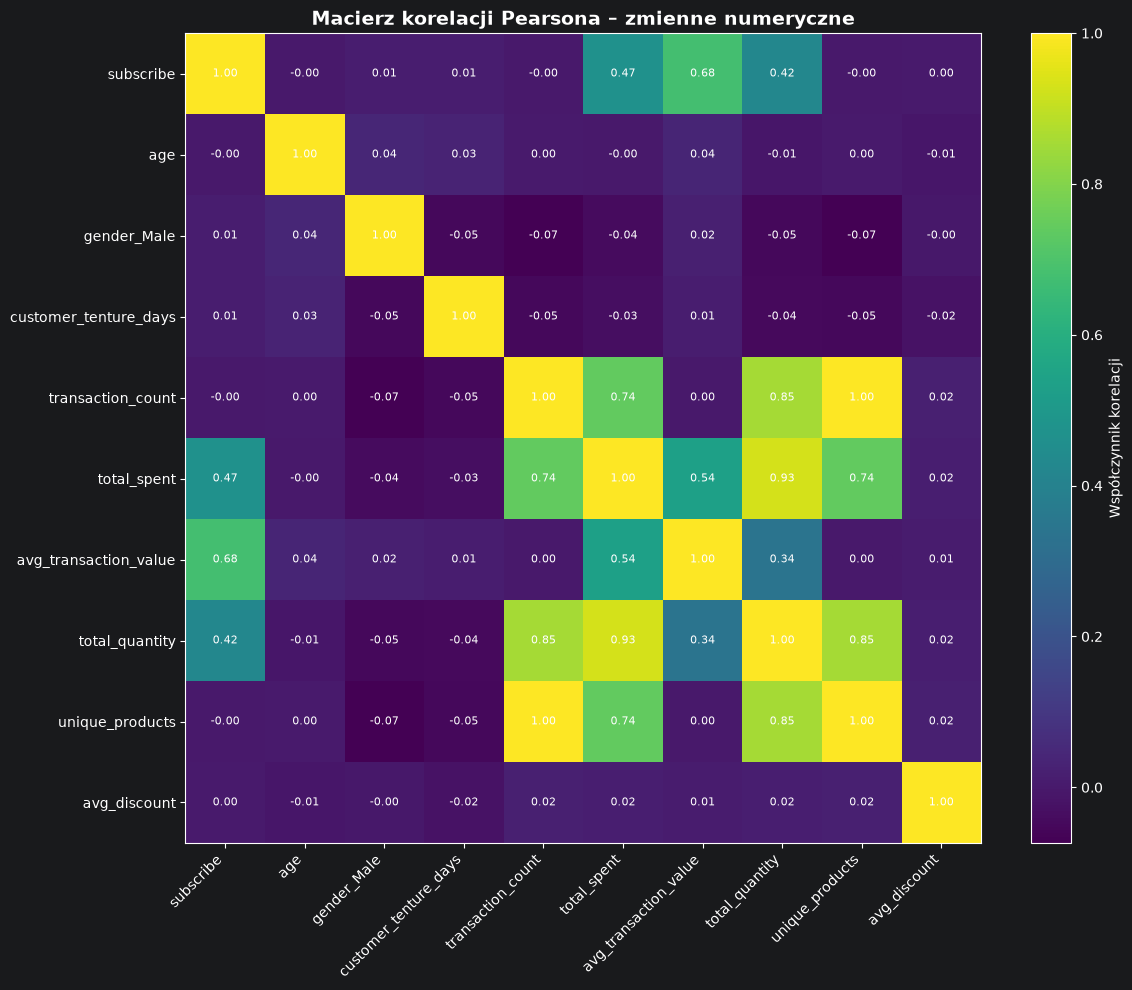

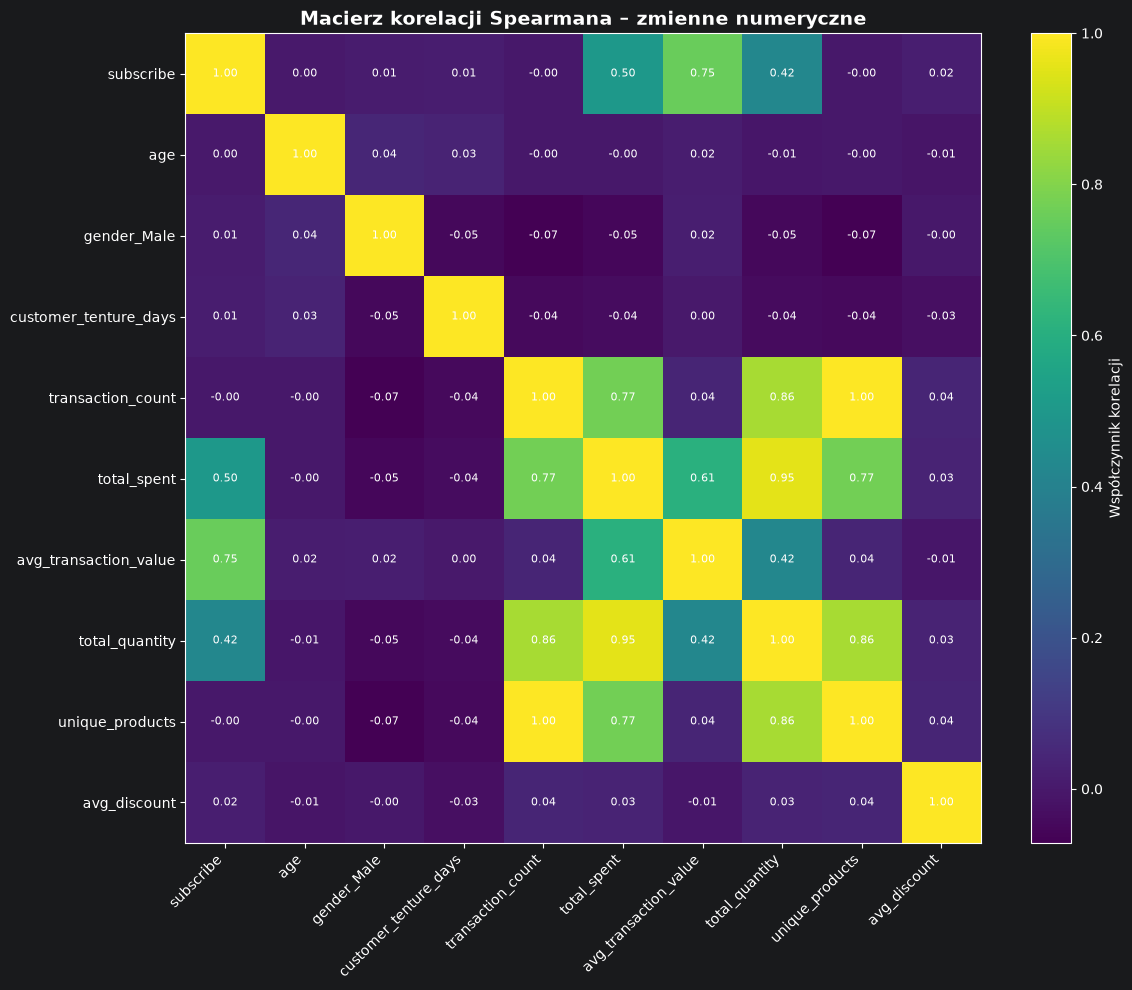

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Macierz korelacji Pearsona
pearson_corr = customers_features[numeric_features].corr(method="pearson")

# Macierz korelacji Spearmana
spearman_corr = customers_features[numeric_features].corr(method="spearman")


# Funkcja do tworzenia wykresu macierzy korelacji
def plot_correlation_matrix(corr_matrix, title):

    fig, ax = plt.subplots(figsize=(12, 10))

    # Rysowanie macierzy
    im = ax.imshow(
        corr_matrix,
        interpolation="nearest",
        aspect="auto"
    )

    # Pasek skali
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Współczynnik korelacji")

    # Ustawienie nazw kolumn i wierszy
    ax.set_xticks(np.arange(len(corr_matrix.columns)))
    ax.set_yticks(np.arange(len(corr_matrix.index)))

    ax.set_xticklabels(
        corr_matrix.columns,
        rotation=45,
        ha="right"
    )

    ax.set_yticklabels(
        corr_matrix.index
    )

    # Dodanie wartości korelacji do komórek
    for i in range(len(corr_matrix.index)):
        for j in range(len(corr_matrix.columns)):

            ax.text(
                j,
                i,
                f"{corr_matrix.iloc[i, j]:.2f}",
                ha="center",
                va="center",
                fontsize=8
            )

    # Tytuł
    ax.set_title(
        title,
        fontsize=14,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()


# ==========================================
# MACIERZ KORELACJI PEARSONA
# ==========================================

plot_correlation_matrix(
    pearson_corr,
    "Macierz korelacji Pearsona – zmienne numeryczne"
)


# ==========================================
# MACIERZ KORELACJI SPEARMANA
# ==========================================

plot_correlation_matrix(
    spearman_corr,
    "Macierz korelacji Spearmana – zmienne numeryczne"
)

In [4]:
#Podsumowanie korelacji z subscribe:
customers_features[["total_spent","avg_transaction_value","total_quantity","subscribe"]].corr(method="pearson")["subscribe"].drop("subscribe").sort_values(ascending=False)

avg_transaction_value    0.680035
total_spent              0.471364
total_quantity           0.421283
Name: subscribe, dtype: float64

Z macieży korelacji wynika, że "subscribe" jest najbardziej zależne od "total_spent","avg_transaction_value","total_quantity".
W z związku z tym określamy percentyle dla tych kolumn.

In [5]:
customers_features[["total_spent","avg_transaction_value","total_quantity"]].describe(percentiles=np.arange(0.1, 1.0, 0.1)).round(2).T

,count,mean,std,min,10%,20%,30%,40%,50%,60%,70%,80%,90%,max
total_spent,1000.0,55792794.30,39664673.07,8400.0,10450930.00,18792000.0,28667500.00,37165800.00,48816500.00,59718200.0,73609000.00,91114800.00,111037200.0,250201000.0
avg_transaction_value,1000.0,6802235.77,3408846.99,8400.0,2636052.73,3628740.0,4802853.33,6188538.46,6969222.22,7664360.0,8395364.29,9124660.61,10500650.0,48790000.0
total_quantity,1000.0,183.46,114.48,1.0,38.00,71.0,106.00,137.00,167.50,204.0,243.00,296.00,346.0,753.0


## Wizualizacje

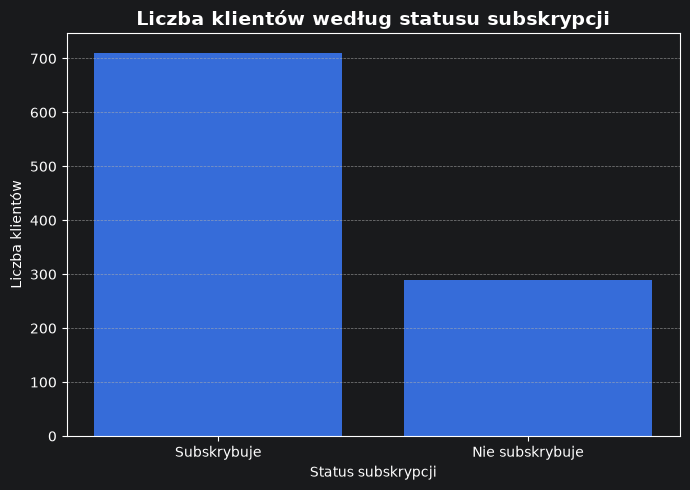

In [16]:
subscribe_counts = customers_features["subscribe"].value_counts()

fig, ax = plt.subplots(figsize=(7, 5))

ax.bar(
    ["Subskrybuje", "Nie subskrybuje"],
    subscribe_counts.values
)

ax.set_title(
    "Liczba klientów według statusu subskrypcji",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Status subskrypcji")
ax.set_ylabel("Liczba klientów")

ax.grid(
    True,
    axis="y",
    linestyle="--",
    alpha=0.7
)

plt.tight_layout()
plt.show()

### Zależność od total spent:

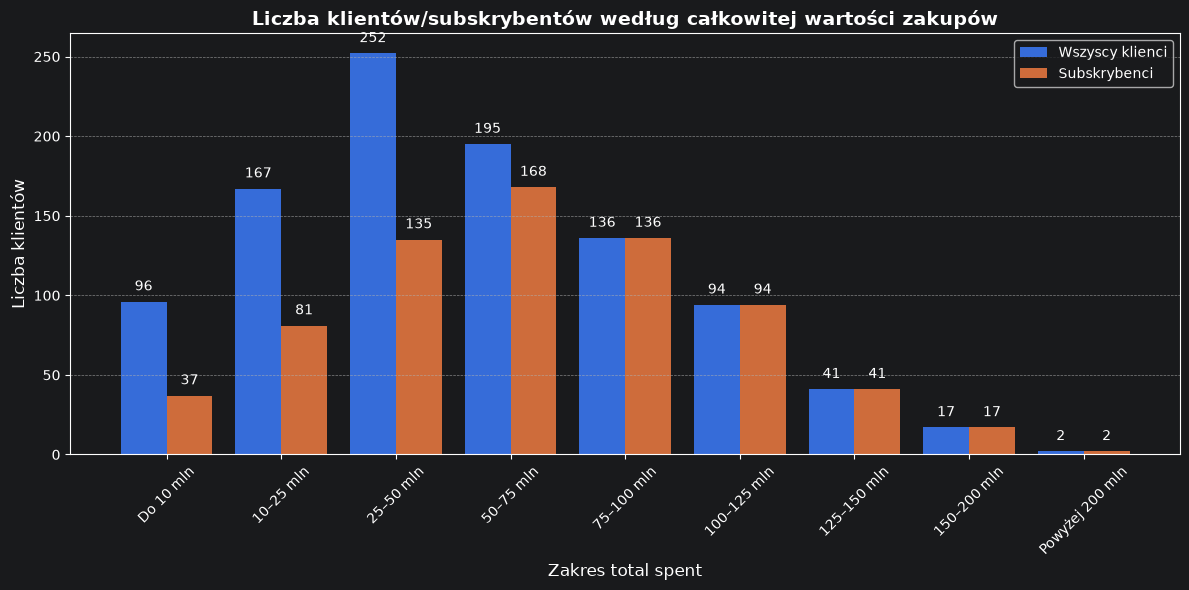

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Definiujemy przedziały na podstawie percentyli
bins = [
    0,
    10_000_000,
    25_000_000,
    50_000_000,
    75_000_000,
    100_000_000,
    125_000_000,
    150_000_000,
    200_000_000,
    float("inf")
]

# Etykiety przedziałów
labels = [
    "Do 10 mln",
    "10–25 mln",
    "25–50 mln",
    "50–75 mln",
    "75–100 mln",
    "100–125 mln",
    "125–150 mln",
    "150–200 mln",
    "Powyżej 200 mln"
]

# Przypisanie każdego klienta do przedziału
customer_spending_groups = pd.cut(
    customers_features["total_spent"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Liczba wszystkich klientów w każdym przedziale
customer_counts = customer_spending_groups.value_counts(
    sort=False
)

# Liczba subskrybentów w każdym przedziale
subscriber_counts = (
    customer_spending_groups[
        customers_features["subscribe"] == 1
    ]
    .value_counts(sort=False)
)

# Pozycje na osi X
x = np.arange(len(labels))

# Szerokość pojedynczego słupka
width = 0.4

# Tworzenie wykresu
fig, ax = plt.subplots(figsize=(12, 6))

# Słupki wszystkich klientów
bars_customers = ax.bar(
    x - width / 2,
    customer_counts.values,
    width,
    label="Wszyscy klienci"
)

# Słupki subskrybentów
bars_subscribers = ax.bar(
    x + width / 2,
    subscriber_counts.values,
    width,
    label="Subskrybenci"
)

# Tytuł
ax.set_title(
    "Liczba klientów/subskrybentów według całkowitej wartości zakupów",
    fontsize=14,
    fontweight="bold"
)

# Osie
ax.set_xlabel(
    "Zakres total spent",
    fontsize=12
)

ax.set_ylabel(
    "Liczba klientów",
    fontsize=12
)

# Etykiety na osi X
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)

# Liczby nad słupkami - wszyscy klienci
for bar in bars_customers:
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 5,
        str(int(height)),
        ha="center",
        va="bottom"
    )

# Liczby nad słupkami - subskrybenci
for bar in bars_subscribers:
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 5,
        str(int(height)),
        ha="center",
        va="bottom"
    )

# Legenda
ax.legend()

# Siatka
ax.grid(
    True,
    axis="y",
    linestyle="--",
    alpha=0.7
)

plt.tight_layout()
plt.show()


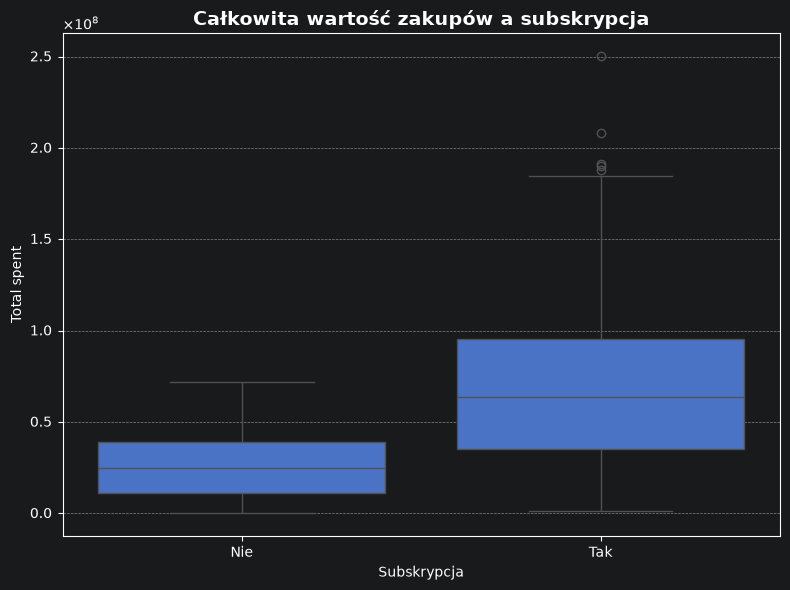

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import ScalarFormatter

fig, ax = plt.subplots(figsize=(8, 6))

sns.boxplot(
    data=customers_features,
    x="subscribe",
    y="total_spent",
    ax=ax
)

# Ustawienie pozycji ticków
ax.set_xticks([0, 1])

# Ustawienie nazw kategorii
ax.set_xticklabels(["Nie", "Tak"])

ax.set_title(
    "Całkowita wartość zakupów a subskrypcja",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Subskrypcja")
ax.set_ylabel("Total spent")

# Formatowanie osi Y
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))

ax.yaxis.set_major_formatter(formatter)

# Siatka
ax.grid(
    True,
    axis="y",
    linestyle="--",
    alpha=0.7
)

plt.tight_layout()
plt.show()

### Zależność od avg_transaction_value

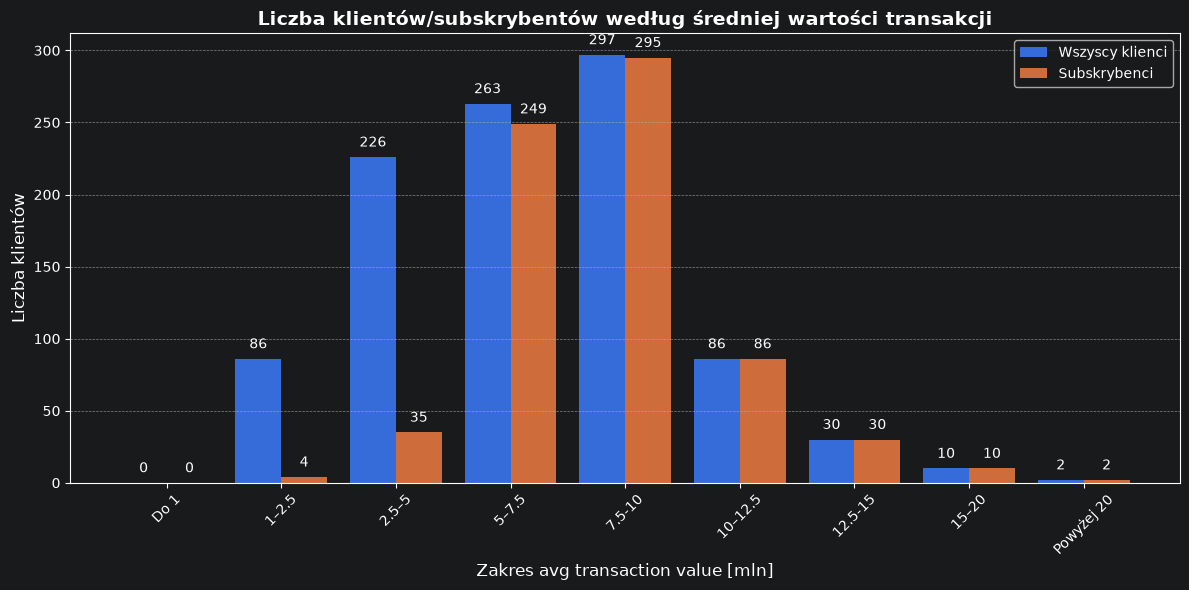

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# AVG TRANSACTION VALUE
# ==========================================

# Definiujemy przedziały średniej wartości transakcji
bins = [
    0,
    5,
    2_500_000,
    5_000_000,
    7_500_000,
    10_000_000,
    12_500_000,
    15_000_000,
    20_000_000,
    float("inf")
]

# Etykiety przedziałów
labels = [
    "Do 1",
    "1–2.5",
    "2.5–5",
    "5–7.5",
    "7.5-10",
    "10–12.5",
    "12.5-15",
    "15–20",
    "Powyżej 20"
]

# Przypisanie klientów do przedziałów
customer_transaction_groups = pd.cut(
    customers_features["avg_transaction_value"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Liczba wszystkich klientów
customer_counts = customer_transaction_groups.value_counts(
    sort=False
)

# Liczba subskrybentów
subscriber_counts = (
    customer_transaction_groups[
        customers_features["subscribe"] == 1
    ]
    .value_counts(sort=False)
)

# Pozycje na osi X
x = np.arange(len(labels))

# Szerokość słupków
width = 0.4

# Tworzenie wykresu
fig, ax = plt.subplots(figsize=(12, 6))

# Wszyscy klienci
bars_customers = ax.bar(
    x - width / 2,
    customer_counts.values,
    width,
    label="Wszyscy klienci"
)

# Subskrybenci
bars_subscribers = ax.bar(
    x + width / 2,
    subscriber_counts.values,
    width,
    label="Subskrybenci"
)

# Tytuł
ax.set_title(
    "Liczba klientów/subskrybentów według średniej wartości transakcji",
    fontsize=14,
    fontweight="bold"
)

# Osie
ax.set_xlabel(
    "Zakres avg transaction value [mln]",
    fontsize=12
)

ax.set_ylabel(
    "Liczba klientów",
    fontsize=12
)

# Etykiety osi X
ax.set_xticks(x)
ax.set_xticklabels(
    labels,
    rotation=45
)

# Liczby nad słupkami
for bar in bars_customers:
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 5,
        str(int(height)),
        ha="center",
        va="bottom"
    )

for bar in bars_subscribers:
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 5,
        str(int(height)),
        ha="center",
        va="bottom"
    )

# Legenda
ax.legend()

# Siatka
ax.grid(
    True,
    axis="y",
    linestyle="--",
    alpha=0.7
)

plt.tight_layout()
plt.show()

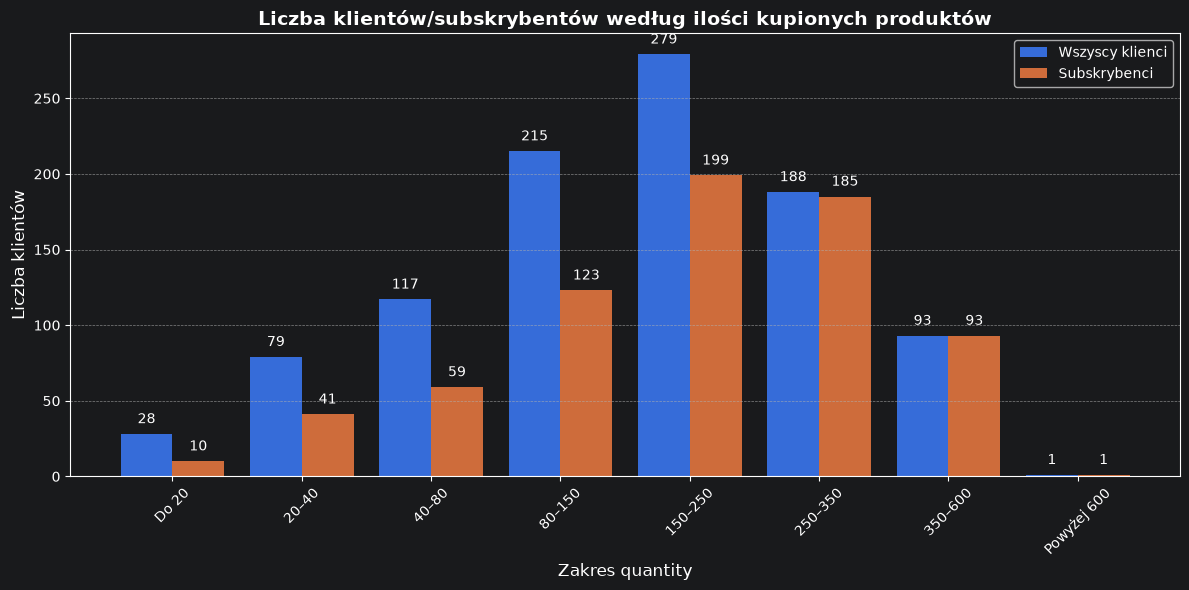

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# AVG TRANSACTION VALUE
# ==========================================

# Definiujemy przedziały
bins = [
    0,
    20,
    40,
    80,
    150,
    250,
    350,
    600,
    float("inf")
]

labels = [
    "Do 20",
    "20–40",
    "40–80",
    "80–150",
    "150–250",
    "250–350",
    "350–600",
    "Powyżej 600"
]

# Przypisanie klientów do przedziałów
customer_transaction_groups = pd.cut(
    customers_features["total_quantity"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Liczba wszystkich klientów
customer_counts = customer_transaction_groups.value_counts(
    sort=False
)

# Liczba subskrybentów
subscriber_counts = (
    customer_transaction_groups[
        customers_features["subscribe"] == 1
    ]
    .value_counts(sort=False)
)

# Pozycje na osi X
x = np.arange(len(labels))

# Szerokość słupków
width = 0.4

# Tworzenie wykresu
fig, ax = plt.subplots(figsize=(12, 6))

# Wszyscy klienci
bars_customers = ax.bar(
    x - width / 2,
    customer_counts.values,
    width,
    label="Wszyscy klienci"
)

# Subskrybenci
bars_subscribers = ax.bar(
    x + width / 2,
    subscriber_counts.values,
    width,
    label="Subskrybenci"
)

# Tytuł
ax.set_title(
    "Liczba klientów/subskrybentów według ilości kupionych produktów",
    fontsize=14,
    fontweight="bold"
)

# Osie
ax.set_xlabel(
    "Zakres quantity",
    fontsize=12
)

ax.set_ylabel(
    "Liczba klientów",
    fontsize=12
)

# Etykiety osi X
ax.set_xticks(x)
ax.set_xticklabels(
    labels,
    rotation=45
)

# Liczby nad słupkami
for bar in bars_customers:
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 5,
        str(int(height)),
        ha="center",
        va="bottom"
    )

for bar in bars_subscribers:
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 5,
        str(int(height)),
        ha="center",
        va="bottom"
    )

# Legenda
ax.legend()

# Siatka
ax.grid(
    True,
    axis="y",
    linestyle="--",
    alpha=0.7
)

plt.tight_layout()
plt.show()

## Detekcja outlierów metodą IQR

In [33]:
def detect_outliers_iqr(df, columns):
    outlier_summary = {}

    for column in columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)

        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[
            (df[column] < lower_bound) |
            (df[column] > upper_bound)
        ]

        outlier_summary[column] = {
            "Q1": Q1,
            "Q3": Q3,
            "IQR": IQR,
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "outlier_count": len(outliers)
        }

    return pd.DataFrame(outlier_summary).T

outlier_features = [
    "age",
    "customer_tenture_days",
    "transaction_count",
    "total_spent",
    "unique_products",
    "avg_transaction_value",
    "total_quantity"
]

outlier_summary = detect_outliers_iqr(
    customers_features,
    outlier_features
)

outlier_summary

,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count
age,2.900000e+01,52.00,2.300000e+01,-5.500000e+00,8.650000e+01,0.0
customer_tenture_days,1.887500e+02,533.00,3.442500e+02,-3.276250e+02,1.049375e+03,0.0
transaction_count,4.000000e+00,12.00,8.000000e+00,-8.000000e+00,2.400000e+01,1.0
total_spent,2.379925e+07,81868500.00,5.806925e+07,-6.330462e+07,1.689724e+08,9.0
unique_products,4.000000e+00,12.00,8.000000e+00,-8.000000e+00,2.400000e+01,1.0
avg_transaction_value,4.139714e+06,8723183.33,4.583469e+06,-2.735489e+06,1.559839e+07,9.0
total_quantity,8.900000e+01,265.00,1.760000e+02,-1.750000e+02,5.290000e+02,2.0


In [49]:
def show_outliers(df, columns):

    for column in columns:

        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)

        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[
            (df[column] < lower_bound) |
            (df[column] > upper_bound)
        ]
        if len(outliers) > 0:
            print(f"\n{'=' * 60}")
            print(f"CECHA: {column}")
            print(f"Dolna granica: {lower_bound:.2f}")
            print(f"Górna granica: {upper_bound:.2f}")
            print(f"Liczba outlierów: {len(outliers)}")
            print(f"Id klienta oraz wartość outlier:\n{outliers[['customer_id',column]]}")
            print(f"{'=' * 60}")


show_outliers(
    customers_features,
    outlier_features
)


CECHA: transaction_count
Dolna granica: -8.00
Górna granica: 24.00
Liczba outlierów: 1
Id klienta oraz wartość outlier:
    customer_id  transaction_count
611    CUST0860                 27

CECHA: total_spent
Dolna granica: -63304625.00
Górna granica: 168972375.00
Liczba outlierów: 9
Id klienta oraz wartość outlier:
    customer_id  total_spent
213    CUST0210    184352000
346    CUST0342    176111000
385    CUST0381    190986000
438    CUST0738    190232000
611    CUST0860    250201000
624    CUST0621    188095000
627    CUST0624    173060000
765    CUST0765    171944000
801    CUST0801    208310000

CECHA: unique_products
Dolna granica: -8.00
Górna granica: 24.00
Liczba outlierów: 1
Id klienta oraz wartość outlier:
    customer_id  unique_products
611    CUST0860               27

CECHA: avg_transaction_value
Dolna granica: -2735489.28
Górna granica: 15598386.90
Liczba outlierów: 9
Id klienta oraz wartość outlier:
    customer_id  avg_transaction_value
180    CUST0177            19

## Podsumowanie

W pierwszym etapie przeprowadzono kontrolę jakości danych w tabelach customers i transactions. Usunięto zduplikowane rekordy klientów, które były identycznymi kopiami. Braki w zmiennej age uzupełniono medianą, natomiast braki w pozostałych kolumnach przeanalizowano pod kątem ich znaczenia biznesowego.

Poprawiono typy danych, m.in. przekonwertowano kolumny zawierające daty na typ datetime, a wybrane zmienne tekstowe na typ category. Zmienną docelową subscribe zakodowano binarnie jako 0/1.

Następnie wykonano feature engineering. Na podstawie danych transakcyjnych utworzono m.in. wartość pojedynczej transakcji, liczbę transakcji klienta, całkowitą wartość zakupów, średnią wartość transakcji, łączną liczbę zakupionych sztuk oraz liczbę unikalnych produktów. Dane transakcyjne zagregowano do poziomu customer_id i połączono z tabelą klientów, uzyskując jedną tabelę analityczną, w której jeden wiersz odpowiada jednemu klientowi.

W ramach eksploracyjnej analizy danych obliczono statystyki opisowe dla kluczowych zmiennych liczbowych oraz przeanalizowano rozkłady zmiennych, zależności między cechami a zmienną docelową subscribe oraz korelacje pomiędzy zmiennymi liczbowymi. Przeprowadzono również detekcję wartości odstających metodą IQR. Wartości odstające nie są automatycznie usuwane, ponieważ mogą reprezentować rzeczywiste zachowania klientów. Ich wpływ na model zostanie oceniony na dalszym etapie.